# Clustering jerárquico: ejemplo clásico con Iris

Este notebook usa un dataset clásico y muy citado en clustering: **Iris**. Aquí lo empleamos para mostrar una alternativa muy útil a K-Means: el **clustering jerárquico aglomerativo**. En lugar de buscar centroides, el método construye una jerarquía de agrupaciones a partir de distancias entre observaciones y permite interpretar visualmente la estructura por medio de un dendrograma.

También aparecen otros ejemplos clásicos de datasets para clustering, como Old Faithful y Wholesale Customers, que sirven para comparar cómo se comporta la misma idea en distintos tipos de datos.

Referencias web consultadas:
- UCI Iris: https://archive.ics.uci.edu/dataset/53/iris
- Ejemplos de seaborn: https://seaborn.pydata.org/generated/seaborn.load_dataset.html


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

SEMILLA = 42
RANGO_K = range(2, 11)


def evaluar_clustering(X_data, etiquetas):
    return {
        'silhouette': silhouette_score(X_data, etiquetas),
        'calinski_harabasz': calinski_harabasz_score(X_data, etiquetas),
        'davies_bouldin': davies_bouldin_score(X_data, etiquetas),
    }


def resumir_clusters(df_original, etiquetas):
    resumen = df_original.copy()
    resumen['cluster'] = etiquetas
    return resumen.groupby('cluster').mean(numeric_only=True).round(2)


def graficar_resultados_2d(df_2d, etiquetas, x_col, y_col, titulo):
    df_plot = df_2d[[x_col, y_col]].copy()
    df_plot['cluster'] = etiquetas
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_plot, x=x_col, y=y_col, hue='cluster', palette='tab10', s=60, alpha=0.8)
    plt.title(titulo)
    plt.tight_layout()


def graficar_dendrograma(X_data, titulo):
    Z = linkage(X_data, method='ward', metric='euclidean')
    plt.figure(figsize=(10, 6))
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_font_size=8)
    plt.title(titulo)
    plt.xlabel('Observación / cluster')
    plt.ylabel('Distancia')
    plt.tight_layout()


## 1. Carga y comprensión del dataset

Usamos el dataset Iris como ejemplo clásico de clustering. Aunque tiene etiquetas reales, aquí las tratamos solo como referencia para evaluar si el clustering jerárquico recupera grupos naturales.


In [2]:
iris = load_iris(as_frame=True)
X = iris.data.copy()
y = iris.target.copy()

libros = pd.DataFrame({
    'dataset': ['Iris'],
    'fuente': ['UCI / sklearn'],
    'observaciones': [X.shape[0]],
    'variables': [X.shape[1]],
    'clases_reales': [len(np.unique(y))],
})

display(libros)
display(X.head())
print(iris.DESCR.split('\n')[0])

,dataset,fuente,observaciones,variables,clases_reales
0,Iris,UCI / sklearn,150,4,3


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


.. _iris_dataset:


## 2. Preparación de variables

Como el clustering jerárquico también depende de distancias, primero estandarizamos las variables numéricas. La visualización se hace con dos variables originales estandarizadas para facilitar la interpretación.


Variables estandarizadas para clustering jerárquico.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


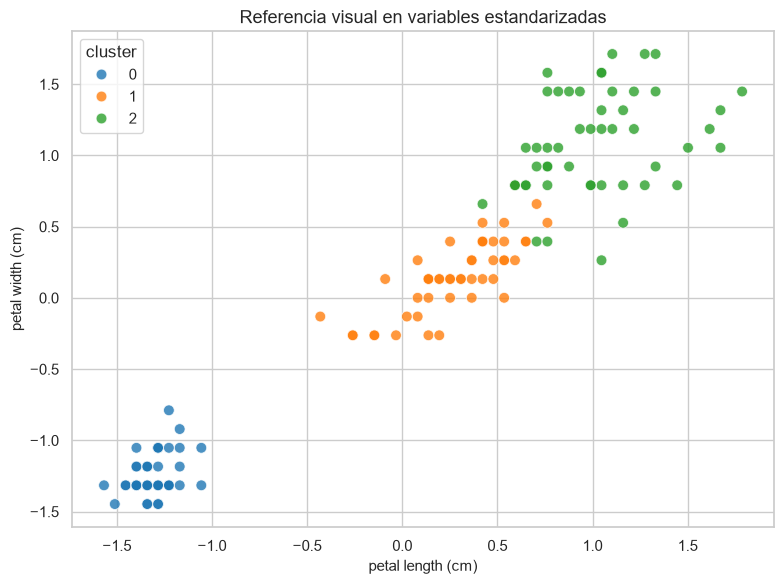

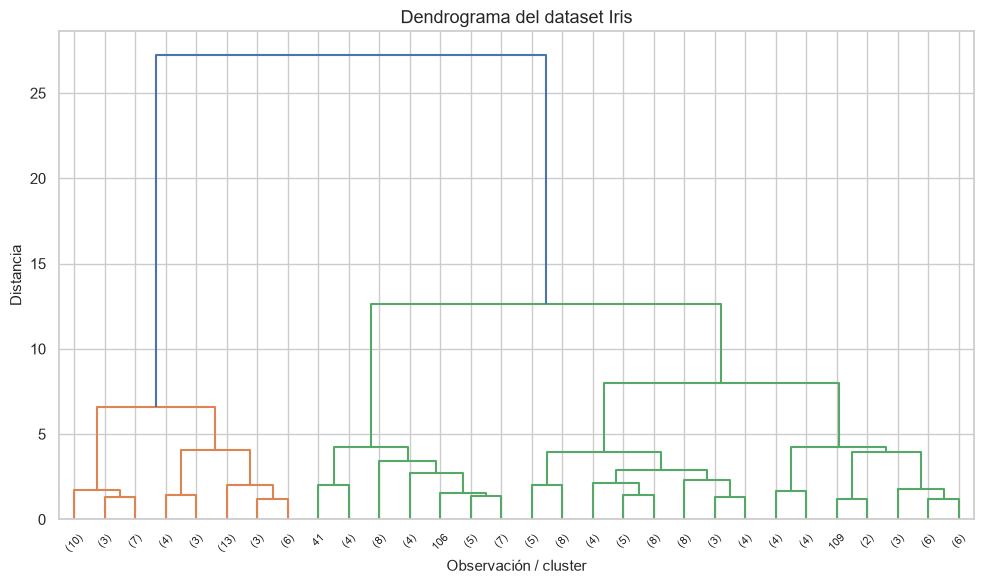

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('Variables estandarizadas para clustering jerárquico.')
display(X_scaled_df.head())

graficar_resultados_2d(X_scaled_df, y, 'petal length (cm)', 'petal width (cm)', 'Referencia visual en variables estandarizadas')
graficar_dendrograma(X_scaled, 'Dendrograma del dataset Iris')


## 3. Selección de k y evaluación de clustering

Usamos varias métricas internas para comparar soluciones con distinto número de clusters: silhouette, Calinski-Harabasz y Davies-Bouldin. En clustering jerárquico, el número de clusters se fija al final a partir de la estructura de la jerarquía.


,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.5770,240.2457,0.5917
1,3,0.4467,222.7192,0.8035
2,4,0.4006,201.2515,0.9788
3,5,0.3306,192.6813,0.9742
4,6,0.3149,172.1230,0.9895
5,7,0.3170,161.7142,0.9706
6,8,0.3109,156.5682,0.9467
7,9,0.3114,155.6855,0.8787
8,10,0.3161,159.6041,0.9283


Mejor k sugerido por silhouette/Calinski-Harabasz: 2


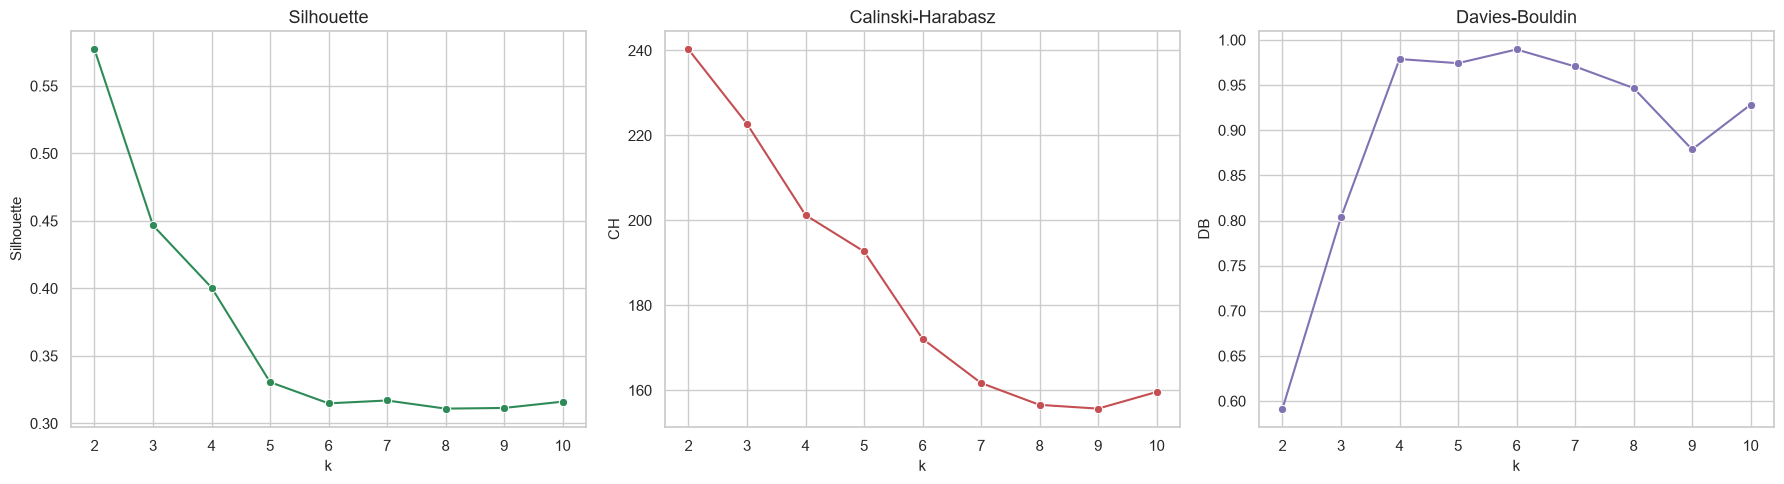

In [4]:
resultados_k = []

for k in RANGO_K:
    modelo = AgglomerativeClustering(n_clusters=k, linkage='ward')
    etiquetas = modelo.fit_predict(X_scaled)
    metricas = evaluar_clustering(X_scaled, etiquetas)
    resultados_k.append({
        'k': k,
        **metricas,
    })

resultados_k = pd.DataFrame(resultados_k)
display(resultados_k.round(4))

mejor_k = int(resultados_k.sort_values(['silhouette', 'calinski_harabasz'], ascending=[False, False]).iloc[0]['k'])
print(f'Mejor k sugerido por silhouette/Calinski-Harabasz: {mejor_k}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=resultados_k, x='k', y='silhouette', marker='o', ax=axes[0], color='#2e8b57')
axes[0].set_title('Silhouette')
axes[0].set_ylabel('Silhouette')

sns.lineplot(data=resultados_k, x='k', y='calinski_harabasz', marker='o', ax=axes[1], color='#c44e52')
axes[1].set_title('Calinski-Harabasz')
axes[1].set_ylabel('CH')

sns.lineplot(data=resultados_k, x='k', y='davies_bouldin', marker='o', ax=axes[2], color='#8172b3')
axes[2].set_title('Davies-Bouldin')
axes[2].set_ylabel('DB')

plt.tight_layout()


## 4. Modelo final e interpretación

Con el mejor $k$ estimado, ajustamos el clustering jerárquico final, resumimos el perfil de cada cluster y lo contrastamos con las clases reales del dataset para ver hasta qué punto la partición recupera la estructura conocida.


Perfil promedio por cluster:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,6.24,2.87,4.87,1.66
1,5.02,3.45,1.47,0.24


Cruce cluster vs clase real:


clase_real,0,1,2
cluster,,,
0,1,50,50
1,49,0,0


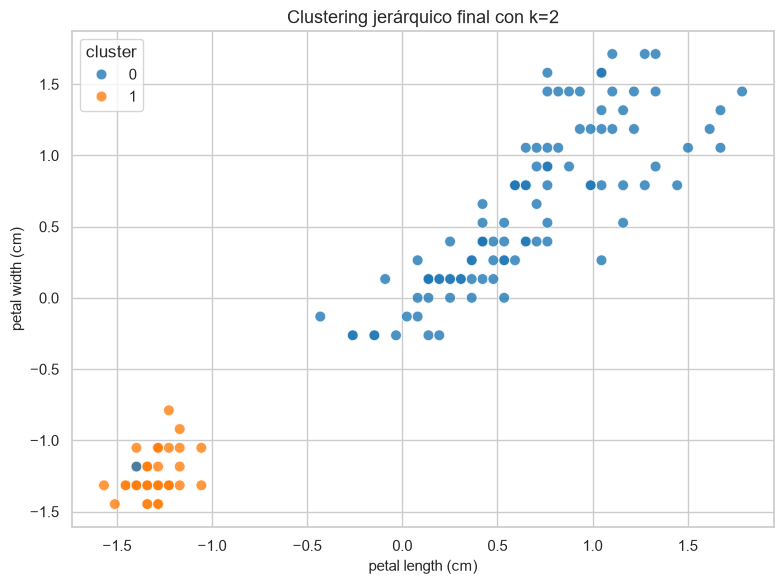

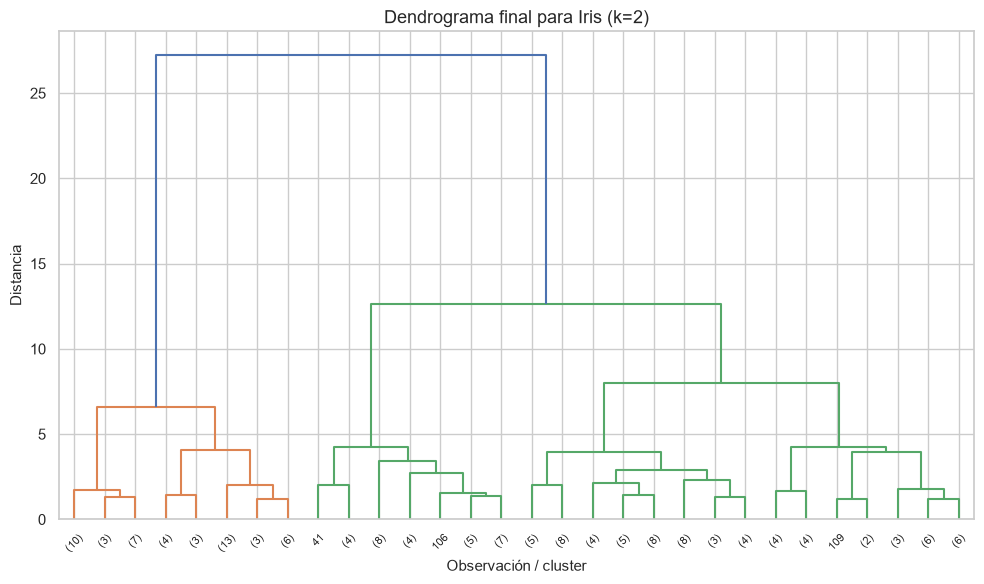

In [5]:
modelo_final = AgglomerativeClustering(n_clusters=mejor_k, linkage='ward')
etiquetas = modelo_final.fit_predict(X_scaled)

perfil_cluster = resumir_clusters(X, etiquetas)
indices_cluster = pd.DataFrame({'cluster': etiquetas, 'clase_real': y})
cruce = pd.crosstab(indices_cluster['cluster'], indices_cluster['clase_real'])

print('Perfil promedio por cluster:')
display(perfil_cluster)
print('Cruce cluster vs clase real:')
display(cruce)

graficar_resultados_2d(X_scaled_df, etiquetas, 'petal length (cm)', 'petal width (cm)', f'Clustering jerárquico final con k={mejor_k}')
graficar_dendrograma(X_scaled, f'Dendrograma final para Iris (k={mejor_k})')


## 5. Conclusiones

- Iris es un ejemplo clásico y pequeño, ideal para mostrar clustering jerárquico con variables estandarizadas.
- A diferencia de K-Means, este enfoque no busca centroides, sino que agrupa observaciones a partir de una estructura de proximidad y permite visualizarla con un dendrograma.
- En clustering conviene no depender de una sola métrica: silhouette, Calinski-Harabasz y Davies-Bouldin dan perspectivas distintas sobre la calidad de la partición.
- En datos con estructura conocida, el cruce con la clase real ayuda a interpretar qué tan bien el algoritmo recupera grupos naturales.
- Si se desea seguir explorando, una extensión natural es comparar clustering jerárquico con K-Means y GMM en el mismo dataset.
- En este ejemplo no se usa PCA: la visualización se hace con variables originales estandarizadas.


## 6. Old Faithful Geyser: segundo ejemplo clásico de clustering

El dataset Old Faithful registra la duración de las erupciones y el tiempo de espera hasta la siguiente erupción del géiser en Yellowstone. Es un ejemplo clásico en la literatura de clustering y aparece en la documentación de R como un conjunto de 272 observaciones y 2 variables: `eruptions` y `waiting`.

Fuente web consultada:
- R documentation: https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/faithful.html
- CSV público de Rdatasets: https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv


,dataset,fuente,observaciones,variables
0,Old Faithful,R datasets / Rdatasets,272,2


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


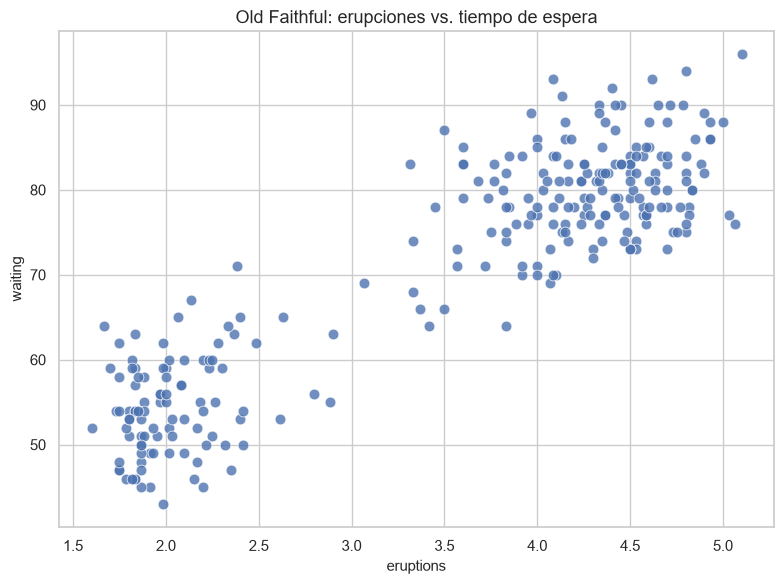

In [6]:
geyser = pd.read_csv('https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv')
geyser = geyser.drop(columns=['rownames'])
geyser_numerico = geyser[['eruptions', 'waiting']].copy()

conteo_geyser = pd.DataFrame({
    'dataset': ['Old Faithful'],
    'fuente': ['R datasets / Rdatasets'],
    'observaciones': [geyser.shape[0]],
    'variables': [geyser_numerico.shape[1]],
})

display(conteo_geyser)
display(geyser.head())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=geyser, x='eruptions', y='waiting', ax=ax, s=60, alpha=0.8, color='#4c72b0')
ax.set_title('Old Faithful: erupciones vs. tiempo de espera')
plt.tight_layout()

### Preparación, estandarización y selección de k

Como en el ejemplo de Iris, estandarizamos las variables antes de aplicar clustering jerárquico y luego comparamos varios valores de $k$ con métricas internas.


Variables estandarizadas para Old Faithful.


,eruptions,waiting
0,0.098499,0.597123
1,-1.481459,-1.245181
2,-0.135861,0.228663
3,-1.057503,-0.655644
4,0.917443,1.039277


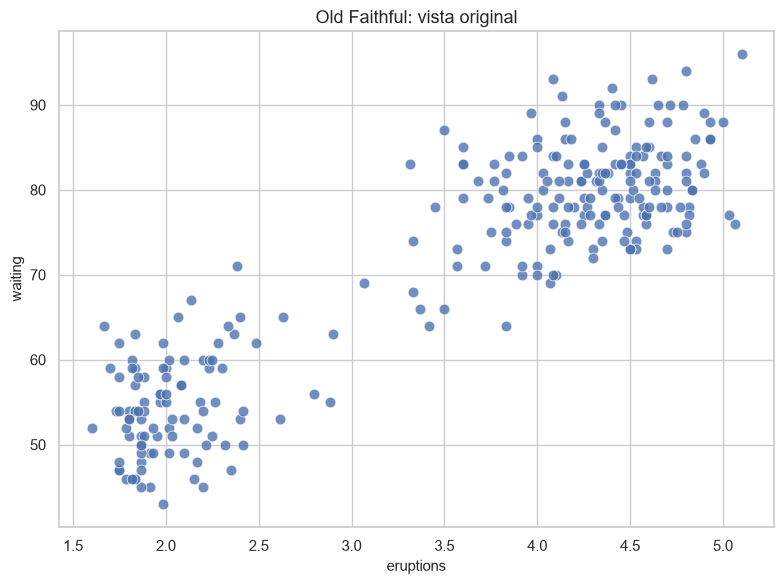

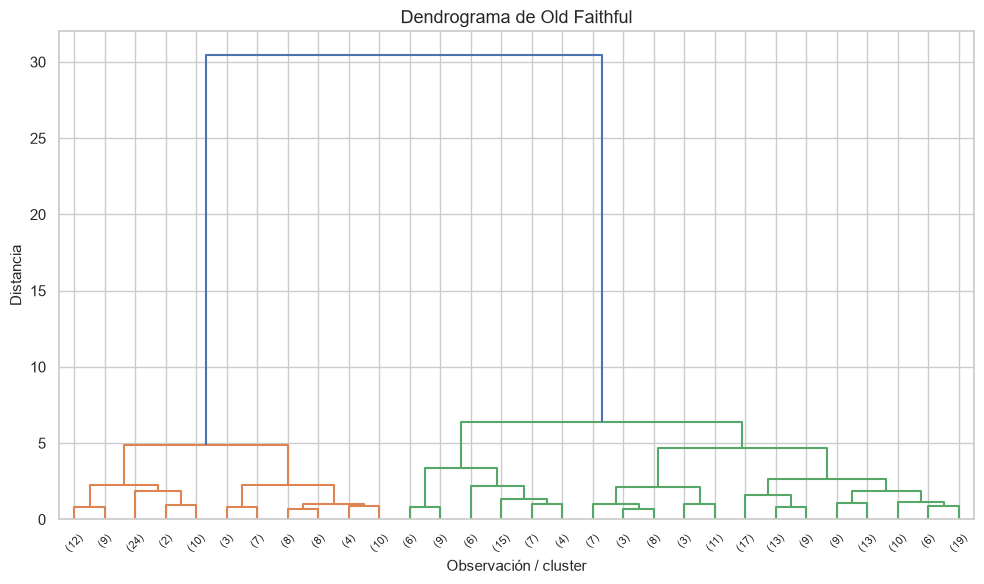

In [7]:
scaler_geyser = StandardScaler()
X_geyser = scaler_geyser.fit_transform(geyser_numerico)
X_geyser_df = pd.DataFrame(X_geyser, columns=geyser_numerico.columns)

print('Variables estandarizadas para Old Faithful.')
display(X_geyser_df.head())

plt.figure(figsize=(8, 6))
sns.scatterplot(data=geyser_numerico, x='eruptions', y='waiting', s=60, alpha=0.8, color='#4c72b0')
plt.title('Old Faithful: vista original')
plt.tight_layout()

graficar_dendrograma(X_geyser, 'Dendrograma de Old Faithful')


### Lectura de negocio

El patrón de Old Faithful suele separarse en dos comportamientos claros: erupciones cortas con esperas cortas y erupciones largas con esperas largas. El clustering jerárquico captura esa separación a partir de la estructura de proximidad entre observaciones, lo que lo convierte en un ejemplo muy útil para explicar segmentación no supervisada en dos variables.


,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.7460,1574.5548,0.3377
1,3,0.4867,1102.6197,0.8414
2,4,0.3867,941.3783,0.9497
3,5,0.3685,940.5798,0.9427
4,6,0.3727,897.6691,0.8460
5,7,0.3390,847.5609,0.9376
6,8,0.3157,803.7385,0.9099
7,9,0.3026,783.8611,0.9572
8,10,0.3090,784.1588,0.9209


Mejor k sugerido para Old Faithful: 2
Perfil promedio por cluster en Old Faithful:


,eruptions,waiting
cluster,,
0,4.29,79.99
1,2.04,54.49


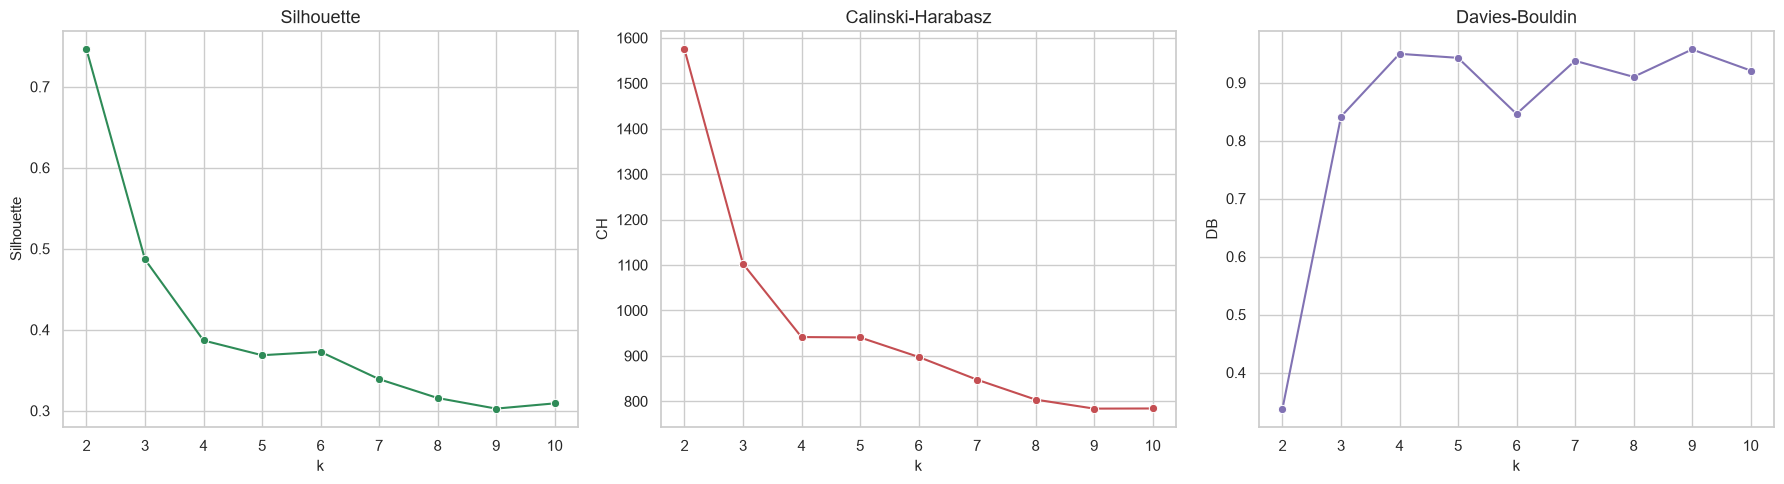

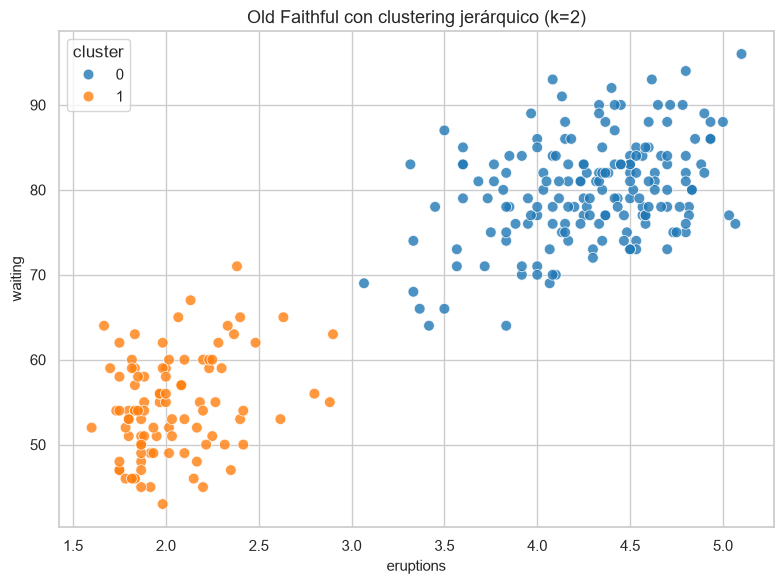

In [8]:
resultados_k_geyser = []

for k in RANGO_K:
    modelo_geyser = AgglomerativeClustering(n_clusters=k, linkage='ward')
    etiquetas_geyser = modelo_geyser.fit_predict(X_geyser)
    metricas = evaluar_clustering(X_geyser, etiquetas_geyser)
    resultados_k_geyser.append({
        'k': k,
        **metricas,
    })

resultados_k_geyser = pd.DataFrame(resultados_k_geyser)
display(resultados_k_geyser.round(4))

mejor_k_geyser = int(resultados_k_geyser.sort_values(['silhouette', 'calinski_harabasz'], ascending=[False, False]).iloc[0]['k'])
print(f'Mejor k sugerido para Old Faithful: {mejor_k_geyser}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=resultados_k_geyser, x='k', y='silhouette', marker='o', ax=axes[0], color='#2e8b57')
axes[0].set_title('Silhouette')
axes[0].set_ylabel('Silhouette')

sns.lineplot(data=resultados_k_geyser, x='k', y='calinski_harabasz', marker='o', ax=axes[1], color='#c44e52')
axes[1].set_title('Calinski-Harabasz')
axes[1].set_ylabel('CH')

sns.lineplot(data=resultados_k_geyser, x='k', y='davies_bouldin', marker='o', ax=axes[2], color='#8172b3')
axes[2].set_title('Davies-Bouldin')
axes[2].set_ylabel('DB')

plt.tight_layout()

modelo_geyser = AgglomerativeClustering(n_clusters=mejor_k_geyser, linkage='ward')
etiquetas_geyser = modelo_geyser.fit_predict(X_geyser)
perfil_geyser = resumir_clusters(geyser_numerico, etiquetas_geyser)

print('Perfil promedio por cluster en Old Faithful:')
display(perfil_geyser)

graficar_resultados_2d(geyser_numerico, etiquetas_geyser, 'eruptions', 'waiting', f'Old Faithful con clustering jerárquico (k={mejor_k_geyser})')


### Conclusiones de Old Faithful

El clustering jerárquico encuentra de forma natural dos grupos bien separados cuando $k=2$, lo que coincide con la intuición visual del conjunto: erupciones cortas con esperas cortas y erupciones largas con esperas largas. Esto convierte a Old Faithful en un ejemplo muy claro para explicar por qué la estandarización previa es importante y por qué la elección de $k$ debe apoyarse en varias métricas, no solo en una vista global del dendrograma.


## 7. Wholesale Customers: tercer ejemplo clásico de clustering

Wholesale Customers es un dataset clásico de UCI sobre clientes de un distribuidor mayorista. Incluye el gasto anual en seis categorías de productos y es muy útil para ilustrar segmentación de clientes con clustering jerárquico.

Fuente web consultada:
- UCI: https://archive.ics.uci.edu/dataset/292/wholesale+customers


,dataset,fuente,observaciones,variables_modelo,variables_totales
0,Wholesale Customers,UCI,440,6,7


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


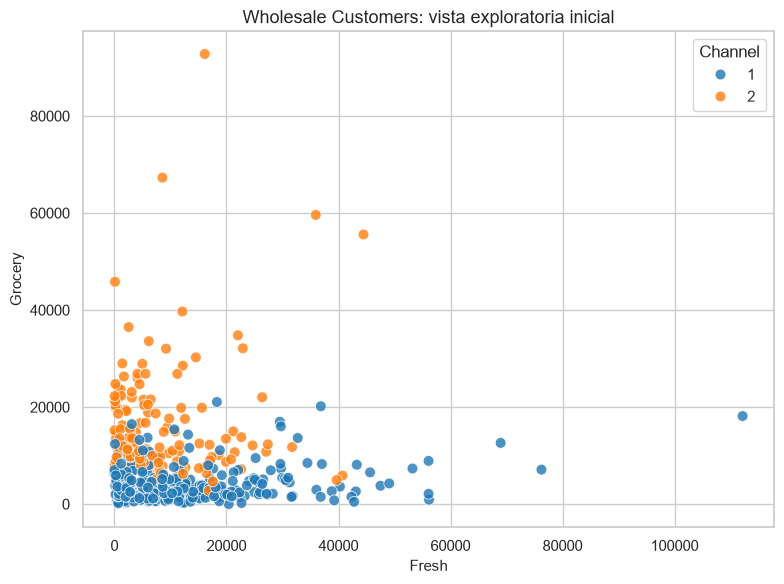

In [9]:
from ucimlrepo import fetch_ucirepo

wholesale = fetch_ucirepo(id=292)
wholesale_X = wholesale.data.features.copy()
wholesale_y = wholesale.data.targets.copy()

columnas_modelo = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
wholesale_numerico = wholesale_X[columnas_modelo].copy()

conteo_wholesale = pd.DataFrame({
    'dataset': ['Wholesale Customers'],
    'fuente': ['UCI'],
    'observaciones': [wholesale_X.shape[0]],
    'variables_modelo': [wholesale_numerico.shape[1]],
    'variables_totales': [wholesale_X.shape[1]],
})

display(conteo_wholesale)
display(wholesale_X.head())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=wholesale_X, x='Fresh', y='Grocery', hue='Channel', palette='tab10', s=60, alpha=0.8, ax=ax)
ax.set_title('Wholesale Customers: vista exploratoria inicial')
plt.tight_layout()

### Preparación y evaluación para Wholesale Customers

Para este conjunto usamos una transformación logarítmica suave sobre las variables de gasto y después estandarizamos. Esto reduce la asimetría de los montos y hace que el clustering jerárquico trabaje con distancias más equilibradas.


Variables de gasto transformadas con log1p y estandarizadas.


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


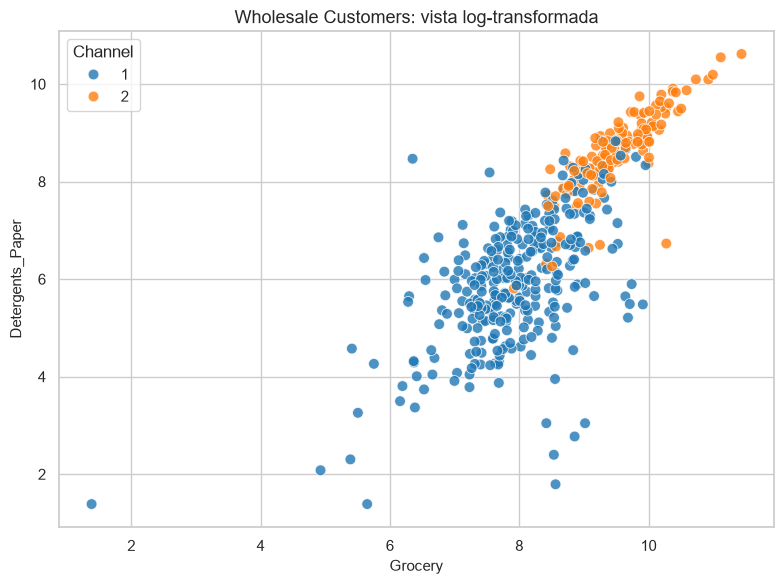

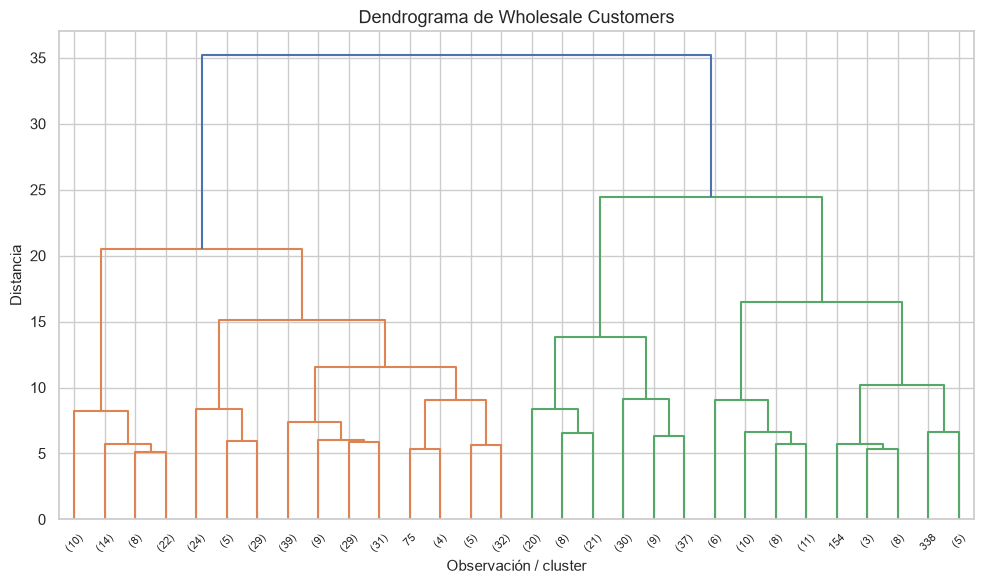

In [10]:
wholesale_log = np.log1p(wholesale_numerico)
scaler_wholesale = StandardScaler()
X_wholesale = scaler_wholesale.fit_transform(wholesale_log)
X_wholesale_df = pd.DataFrame(X_wholesale, columns=columnas_modelo)

print('Variables de gasto transformadas con log1p y estandarizadas.')
display(X_wholesale_df.head())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=wholesale_log, x='Grocery', y='Detergents_Paper', hue=wholesale_X['Channel'], palette='tab10', s=60, alpha=0.8, ax=ax)
ax.set_title('Wholesale Customers: vista log-transformada')
plt.tight_layout()

graficar_dendrograma(X_wholesale, 'Dendrograma de Wholesale Customers')


### Selección de k y lectura de negocio

Buscamos el mejor $k$ con varias métricas internas y luego analizamos la composición de los clusters respecto a `Channel` y `Region`.


,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.2585,134.6245,1.6004
1,3,0.2547,116.7993,1.5390
2,4,0.2021,108.6067,1.5211
3,5,0.2025,100.0146,1.3862
4,6,0.1707,94.8566,1.4895
5,7,0.1633,91.3005,1.4983
6,8,0.1482,86.6125,1.5865
7,9,0.1555,82.0064,1.5492
8,10,0.1218,77.7145,1.5012


Mejor k sugerido para Wholesale Customers: 2


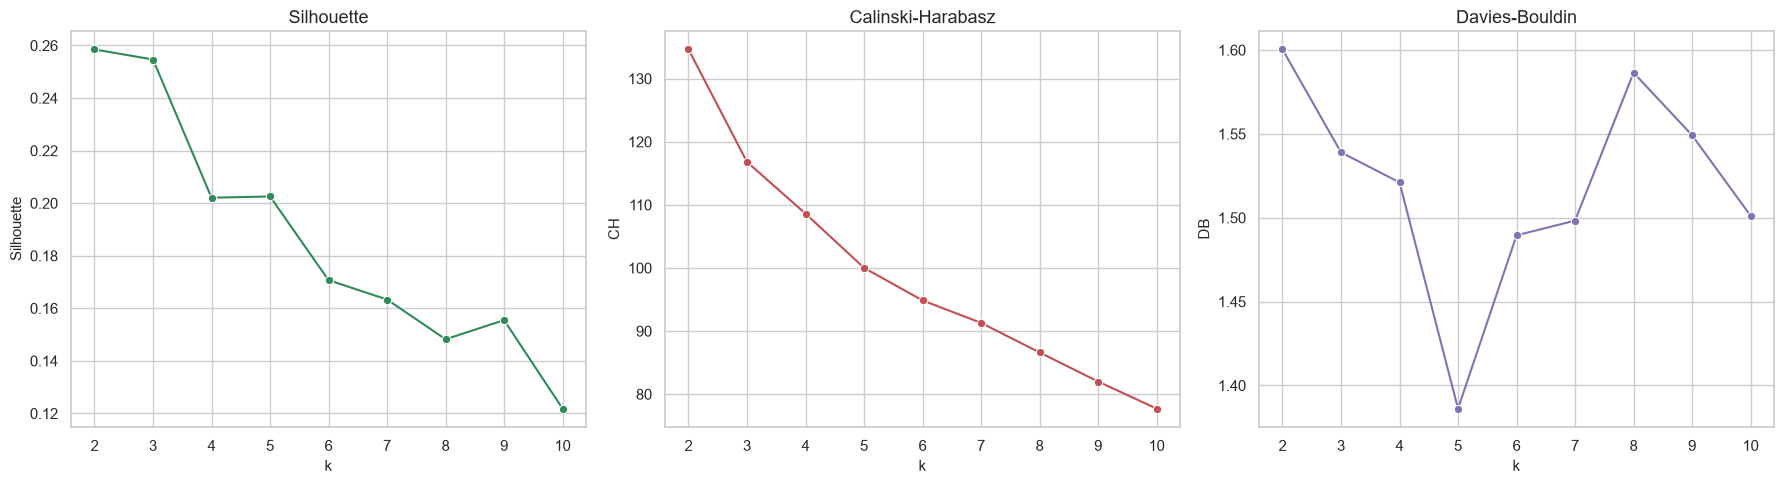

In [11]:
resultados_k_wholesale = []

for k in RANGO_K:
    modelo_wholesale = AgglomerativeClustering(n_clusters=k, linkage='ward')
    etiquetas_wholesale = modelo_wholesale.fit_predict(X_wholesale)
    metricas = evaluar_clustering(X_wholesale, etiquetas_wholesale)
    resultados_k_wholesale.append({
        'k': k,
        **metricas,
    })

resultados_k_wholesale = pd.DataFrame(resultados_k_wholesale)
display(resultados_k_wholesale.round(4))

mejor_k_wholesale = int(resultados_k_wholesale.sort_values(['silhouette', 'calinski_harabasz'], ascending=[False, False]).iloc[0]['k'])
print(f'Mejor k sugerido para Wholesale Customers: {mejor_k_wholesale}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=resultados_k_wholesale, x='k', y='silhouette', marker='o', ax=axes[0], color='#2e8b57')
axes[0].set_title('Silhouette')
axes[0].set_ylabel('Silhouette')

sns.lineplot(data=resultados_k_wholesale, x='k', y='calinski_harabasz', marker='o', ax=axes[1], color='#c44e52')
axes[1].set_title('Calinski-Harabasz')
axes[1].set_ylabel('CH')

sns.lineplot(data=resultados_k_wholesale, x='k', y='davies_bouldin', marker='o', ax=axes[2], color='#8172b3')
axes[2].set_title('Davies-Bouldin')
axes[2].set_ylabel('DB')

plt.tight_layout()


Perfil promedio por cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,7561.31,9338.17,14247.11,1429.40,6214.91,1483.83
1,15016.10,3389.94,3673.95,4187.85,616.81,1552.75


Cruce cluster vs Channel:


Channel,1,2
cluster,,
0,47,131
1,251,11


Cruce cluster vs Region:


Region,1,2,3
cluster,,,
0,26,20,132
1,51,27,184


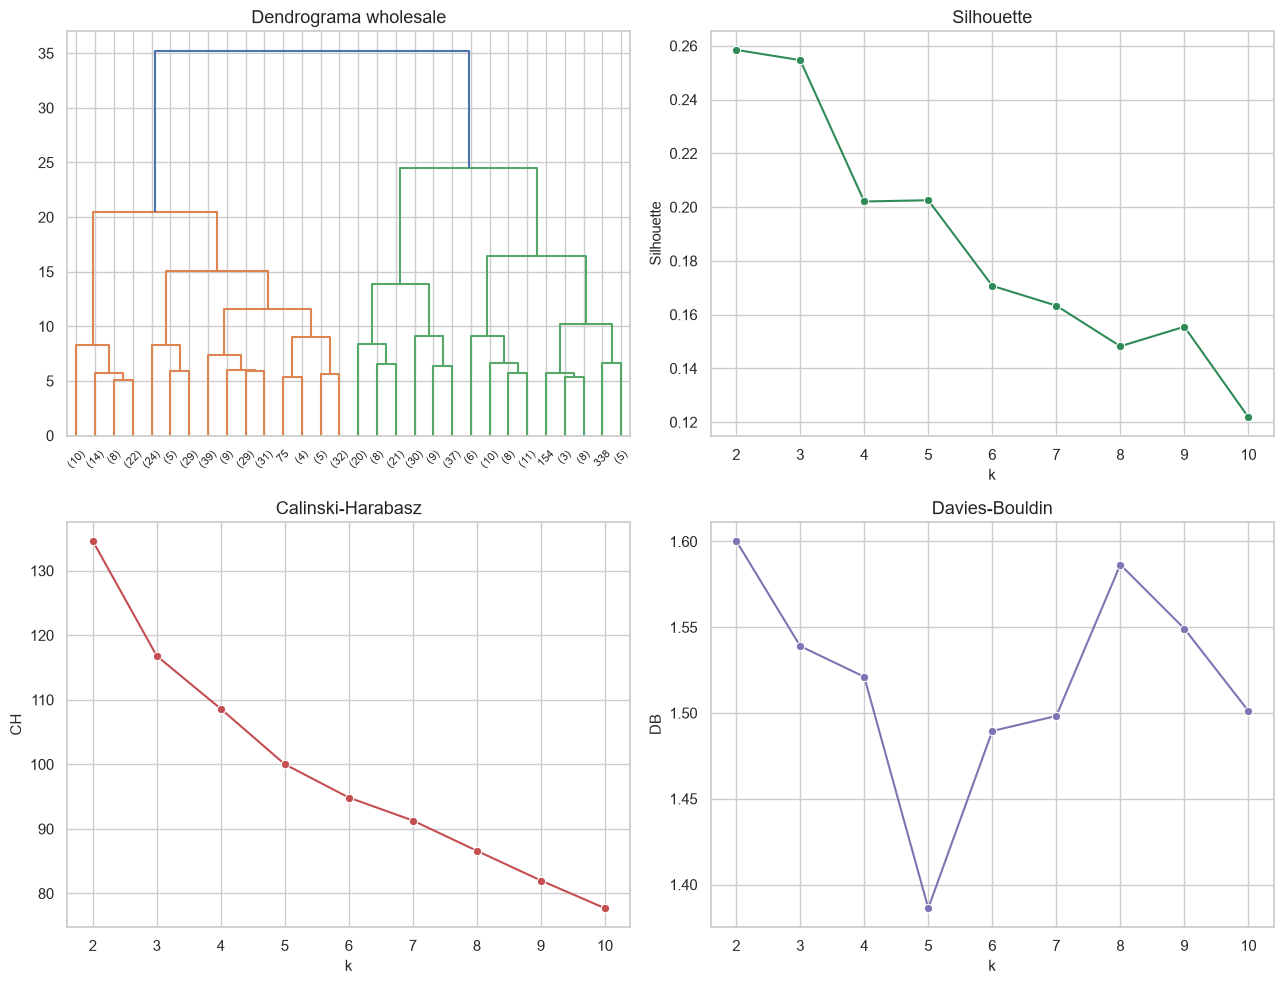

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Dendrograma completo
Z = linkage(X_wholesale, method='ward', metric='euclidean')
ax = axes[0, 0]

dendrogram(Z, truncate_mode='lastp', p=30, leaf_font_size=8, ax=ax)
ax.set_title('Dendrograma wholesale')

# Silhouette
ax = axes[0, 1]
sns.lineplot(data=resultados_k_wholesale, x='k', y='silhouette', marker='o', ax=ax, color='#2e8b57')
ax.set_title('Silhouette')
ax.set_ylabel('Silhouette')

# Calinski-Harabasz
ax = axes[1, 0]
sns.lineplot(data=resultados_k_wholesale, x='k', y='calinski_harabasz', marker='o', ax=ax, color='#c44e52')
ax.set_title('Calinski-Harabasz')
ax.set_ylabel('CH')

# Davies-Bouldin
ax = axes[1, 1]
sns.lineplot(data=resultados_k_wholesale, x='k', y='davies_bouldin', marker='o', ax=ax, color='#8172b3')
ax.set_title('Davies-Bouldin')
ax.set_ylabel('DB')

plt.tight_layout()

modelo_wholesale = AgglomerativeClustering(n_clusters=mejor_k_wholesale, linkage='ward')
etiquetas_wholesale = modelo_wholesale.fit_predict(X_wholesale)

wholesale_resultados = wholesale_X.copy()
wholesale_resultados['cluster'] = etiquetas_wholesale
wholesale_resultados['Region'] = wholesale_y['Region']

perfil_wholesale = wholesale_resultados.groupby('cluster')[columnas_modelo].mean().round(2)
cluster_channel = pd.crosstab(wholesale_resultados['cluster'], wholesale_resultados['Channel'])
cluster_region = pd.crosstab(wholesale_resultados['cluster'], wholesale_resultados['Region'])

print('Perfil promedio por cluster:')
display(perfil_wholesale)
print('Cruce cluster vs Channel:')
display(cluster_channel)
print('Cruce cluster vs Region:')
display(cluster_region)


In [13]:
modelo_wholesale = AgglomerativeClustering(n_clusters=mejor_k_wholesale, linkage='ward')
etiquetas_wholesale = modelo_wholesale.fit_predict(X_wholesale)

wholesale_resultados = wholesale_X.copy()
wholesale_resultados['cluster'] = etiquetas_wholesale
wholesale_resultados['Region'] = wholesale_y['Region']

perfil_wholesale = wholesale_resultados.groupby('cluster')[columnas_modelo].mean().round(2)
cluster_channel = pd.crosstab(wholesale_resultados['cluster'], wholesale_resultados['Channel'])
cluster_region = pd.crosstab(wholesale_resultados['cluster'], wholesale_resultados['Region'])

print('Perfil promedio por cluster:')
display(perfil_wholesale)
print('Cruce cluster vs Channel:')
display(cluster_channel)
print('Cruce cluster vs Region:')
display(cluster_region)


Perfil promedio por cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,7561.31,9338.17,14247.11,1429.40,6214.91,1483.83
1,15016.10,3389.94,3673.95,4187.85,616.81,1552.75


Cruce cluster vs Channel:


Channel,1,2
cluster,,
0,47,131
1,251,11


Cruce cluster vs Region:


Region,1,2,3
cluster,,,
0,26,20,132
1,51,27,184


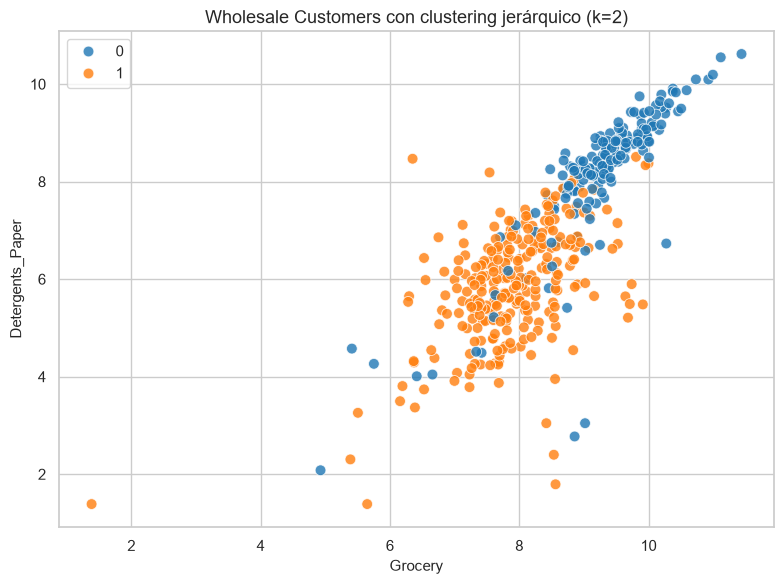

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=wholesale_log, x='Grocery', y='Detergents_Paper', hue=etiquetas_wholesale, palette='tab10', s=60, alpha=0.8, ax=ax)
ax.set_title(f'Wholesale Customers con clustering jerárquico (k={mejor_k_wholesale})')
plt.tight_layout()


### Conclusiones de Wholesale Customers

Wholesale Customers suele producir segmentos claros cuando se trabaja con una transformación logarítmica y estandarización previa. En este ejemplo, el clustering jerárquico permite distinguir perfiles de compra con distinto peso en categorías como Grocery, Detergents_Paper y Fresh, y además deja ver cómo esos grupos se relacionan con `Channel` y `Region`.
